In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import kagglehub

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sentence_transformers import SentenceTransformer

# TEXT PROCESSING

def clean_text(text):
    text = str(text).lower()
    return re.sub(r"[^a-z0-9/ ,]", "", text)


def standardize_ingredients(text, ingredient_map):
    for old, new in ingredient_map.items():
        text = re.sub(rf"\b{re.escape(old)}\b", new, text)
    return text


def filter_ingredients(text):
    ings = [i.strip() for i in text.split(",")]
    return ",".join([
        ing for ing in ings
        if re.search(r"[a-zA-Z]", ing) and len(ing.split()) <= 5
    ])

# RECOMMENDER SYSTEM

class BeautyDupeRecommender:
    def __init__(self):
        self.df = None
        self.tfidf = None
        self.tfidf_matrix = None
        self.model = None
        self.embeddings = None
        self.jaccard_matrix = None
        self.weights = (0.5, 0.3, 0.2)

    # LOAD + CLEAN DATA
    def load_data(self):
        path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")
        df = pd.read_csv(os.path.join(path, "product_info.csv"))

        cols = [
            "product_name", "brand_name", "primary_category",
            "secondary_category", "highlights", "ingredients", "price_usd"
        ]

        df = df[cols].dropna(subset=["ingredients"]).reset_index(drop=True)
        df["highlights"] = df["highlights"].fillna("")

        ingredient_map = {
            "aqua": "water",
            "eau": "water",
            "fragrance parfum": "fragrance",
            "linalool": "fragrance",
            "limonene": "fragrance"
        }

        df["ingredients_clean"] = df["ingredients"].apply(clean_text)
        df["ingredients_clean"] = df["ingredients_clean"].apply(
            lambda x: standardize_ingredients(x, ingredient_map)
        ).apply(filter_ingredients)

        df["highlights_clean"] = df["highlights"].apply(clean_text)
        df["combined_text"] = df["ingredients_clean"] + " " + df["highlights_clean"]

        df["ingredient_list"] = df["ingredients_clean"].apply(lambda x: x.split(","))
        df["ingredient_set"] = df["ingredient_list"].apply(set)

        self.df = df

    # FEATURE ENGINEERING

    def build_features(self):
        # TF-IDF
        self.tfidf = TfidfVectorizer(
            token_pattern=r"(?u)\b\w[\w/]+\b",
            ngram_range=(1, 2),
            max_df=0.85
        )
        self.tfidf_matrix = self.tfidf.fit_transform(self.df["ingredients_clean"])

        # Sentence embeddings
        self.model = SentenceTransformer("all-MiniLM-L6-v2")
        self.embeddings = self.model.encode(
            self.df["combined_text"].tolist(),
            normalize_embeddings=True
        )

        # Jaccard
        mlb = MultiLabelBinarizer()
        X = mlb.fit_transform(self.df["ingredient_list"])
        self.jaccard_matrix = 1 - cosine_similarity(X)

    # Similarity Weights
    def hybrid_score(self, i, j):
        tfidf_score = cosine_similarity(
            self.tfidf_matrix[i],
            self.tfidf_matrix[j]
        )[0][0]

        emb_score = np.dot(self.embeddings[i], self.embeddings[j])

        jac_score = self.jaccard_matrix[i, j]

        w1, w2, w3 = self.weights
        return w1 * tfidf_score + w2 * emb_score + w3 * jac_score

    # RECOMMENDATION ENGINE

    def get_top_dupes(self, idx, top_n=5, category_filter=True, cheaper_only=True):
        query = self.df.iloc[idx]

        scores = []

        for i in range(len(self.df)):
            if i == idx:
                continue

            if category_filter and self.df.iloc[i]["primary_category"] != query["primary_category"]:
                continue

            if cheaper_only and self.df.iloc[i]["price_usd"] > query["price_usd"]:
                continue

            score = self.hybrid_score(idx, i)
            scores.append((i, score))

        scores.sort(key=lambda x: x[1], reverse=True)
        scores = scores[:top_n]

        return pd.DataFrame([
            {
                "product_name": self.df.iloc[i]["product_name"],
                "brand": self.df.iloc[i]["brand_name"],
                "price": self.df.iloc[i]["price_usd"],
                "similarity": float(s)
            }
            for i, s in scores
        ])

    # EVALUATION

    def percent_cheaper(self, sample_size=300, top_n=5):
        idxs = np.random.choice(len(self.df), sample_size, replace=False)

        count, total = 0, 0

        for i in idxs:
            recs = self.get_top_dupes(i, top_n=top_n)

            if len(recs) == 0:
                continue

            total += len(recs)
            count += sum(recs["price"] < self.df.iloc[i]["price_usd"])

        return count / total if total else 0

    # SET WEIGHTS
    def set_weights(self, w1, w2, w3):
        self.weights = (w1, w2, w3)


# RUN EXAMPLE

recommender = BeautyDupeRecommender()

recommender.load_data()
recommender.build_features()

print("Percent cheaper:", recommender.percent_cheaper())

i = random.randint(0, len(recommender.df) - 1)

print("\nQuery:", recommender.df.iloc[i]["product_name"])
print(recommender.get_top_dupes(i))

Using Colab cache for faster access to the 'sephora-products-and-skincare-reviews' dataset.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Percent cheaper: 0.8286666666666667

Query: Eye Bento Bouncy Eyeshadow Trio
                       product_name               brand  price  similarity
0       Mini Star Eyeshadow Palette      Natasha Denona   25.0    0.580803
1            Star Eyeshadow Palette      Natasha Denona   25.0    0.580803
2        Sephora Colorful Eyeshadow  SEPHORA COLLECTION   10.0    0.559450
3                 Trio Face Palette  SEPHORA COLLECTION   15.0    0.557554
4  Soft Matte Perfection Blush Duos  SEPHORA COLLECTION   16.0    0.554780


In [2]:
print("COLUMNS:\n", recommender.df.columns.tolist(), "\n")
print("SHAPE:", recommender.df.shape, "\n")

print("INFO:")
recommender.df.info()

print("\nSUMMARY:")
print(recommender.df.describe())

print("\nMISSING VALUES:")
print(recommender.df.isnull().sum())

COLUMNS:
 ['product_name', 'brand_name', 'primary_category', 'secondary_category', 'highlights', 'ingredients', 'price_usd', 'ingredients_clean', 'highlights_clean', 'combined_text', 'ingredient_list', 'ingredient_set'] 

SHAPE: (7549, 12) 

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7549 entries, 0 to 7548
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_name        7549 non-null   object 
 1   brand_name          7549 non-null   object 
 2   primary_category    7549 non-null   object 
 3   secondary_category  7545 non-null   object 
 4   highlights          7549 non-null   object 
 5   ingredients         7549 non-null   object 
 6   price_usd           7549 non-null   float64
 7   ingredients_clean   7549 non-null   object 
 8   highlights_clean    7549 non-null   object 
 9   combined_text       7549 non-null   object 
 10  ingredient_list     7549 non-null   object 
 11  ing

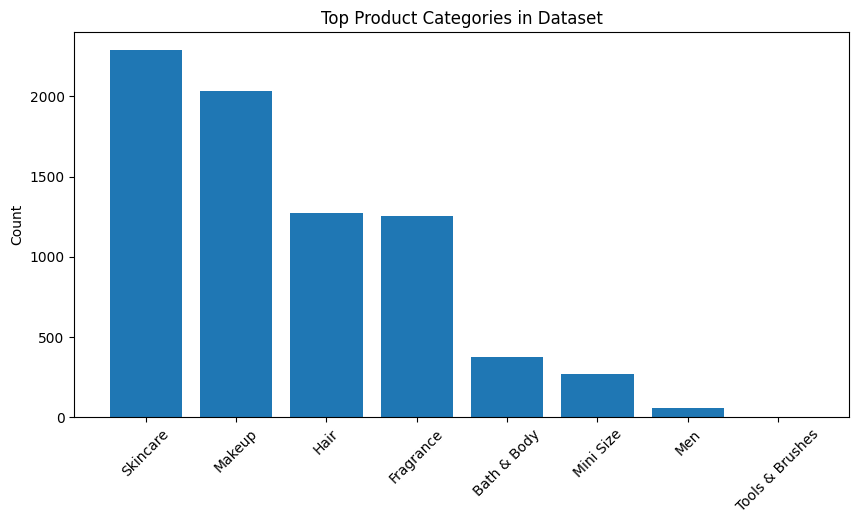

In [3]:
import matplotlib.pyplot as plt

top_cats = recommender.df["primary_category"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_cats.index, top_cats.values)
plt.title("Top Product Categories in Dataset")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

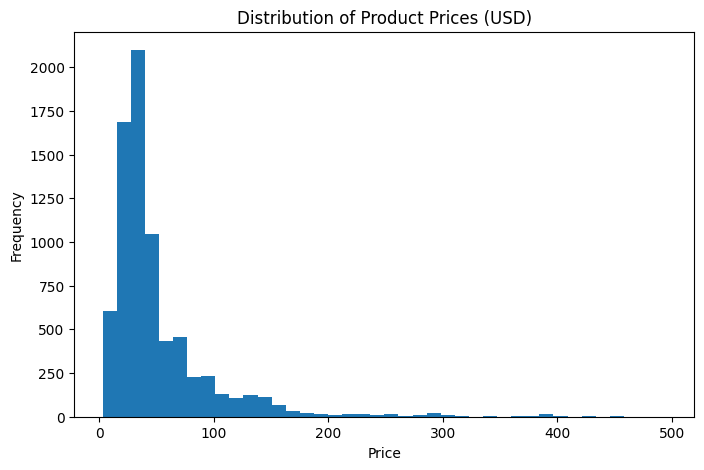

In [4]:
plt.figure(figsize=(8,5))
plt.hist(recommender.df["price_usd"], bins=40)
plt.title("Distribution of Product Prices (USD)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

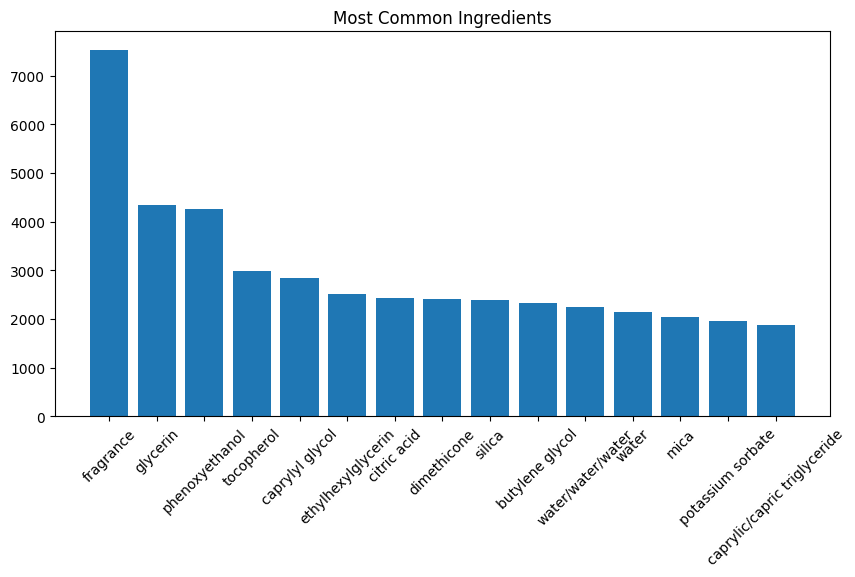

In [5]:
from collections import Counter

all_ingredients = ",".join(recommender.df["ingredients_clean"]).split(",")
counts = Counter(all_ingredients)

top_ings = dict(counts.most_common(15))

plt.figure(figsize=(10,5))
plt.bar(top_ings.keys(), top_ings.values())
plt.title("Most Common Ingredients")
plt.xticks(rotation=45)
plt.show()

In [6]:
result = recommender.percent_cheaper()

print("Percent cheaper:", result)

Percent cheaper: 0.8313333333333334


In [7]:
i = 10  # or random index

query = recommender.df.iloc[i]["product_name"]
results = recommender.get_top_dupes(i)

print("QUERY:", query)
print(results)

QUERY: Rainbow Bar Eau de Parfum Travel Spray
                                product_name  brand  price  similarity
0    L'air Barbes Eau de Parfum Travel Spray  19-69   30.0    0.680558
1     Purple Haze Eau de Parfum Travel Spray  19-69   30.0    0.664015
2          Kasbah Eau de Parfum Travel Spray  19-69   30.0    0.657499
3           Capri Eau de Parfum Travel Spray  19-69   30.0    0.610259
4  Invisible Post Eau de Parfum Travel Spray  19-69   30.0    0.606769


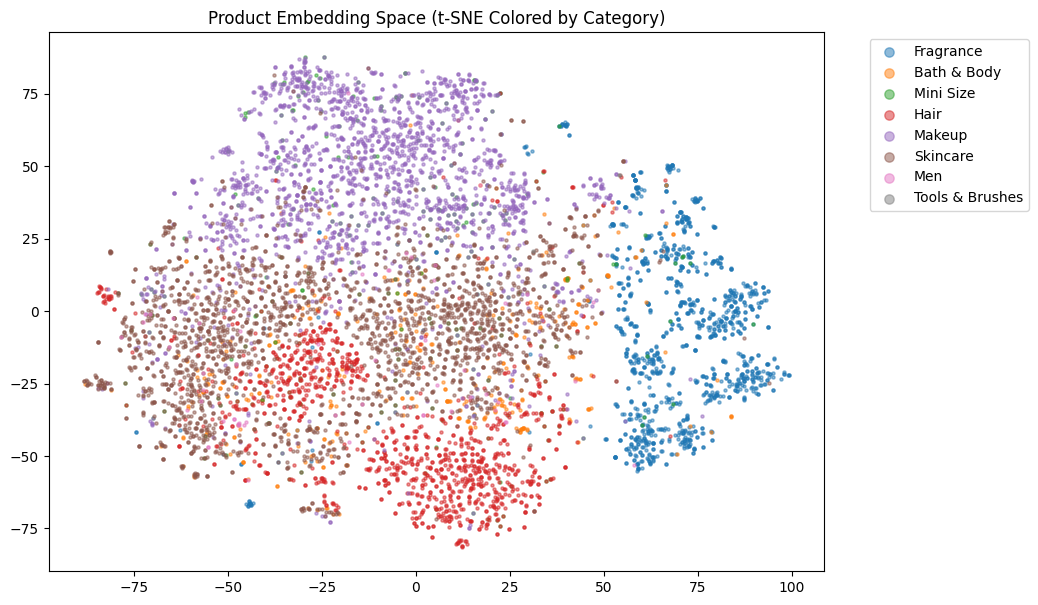

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(recommender.embeddings)

categories = recommender.df["primary_category"]

plt.figure(figsize=(10,7))

for cat in categories.unique():
    idx = categories == cat
    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        s=5,
        alpha=0.5,
        label=cat
    )

plt.title("Product Embedding Space (t-SNE Colored by Category)")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1))
plt.show()

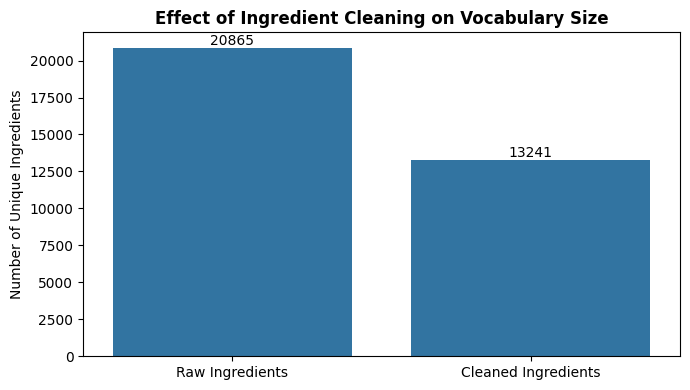

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

raw_unique = set(",".join(recommender.df["ingredients"]).lower().split(","))
before = len(raw_unique)

clean_unique = set(",".join(recommender.df["ingredients_clean"]).split(","))
after = len(clean_unique)

plt.figure(figsize=(7,4))

values = [before, after]
labels = ["Raw Ingredients", "Cleaned Ingredients"]

sns.barplot(x=labels, y=values)

# Add exact values on top of bars (VERY important for posters)
for i, v in enumerate(values):
    plt.text(i, v + (0.01 * max(values)), str(v), ha='center', fontsize=10)

plt.ylabel("Number of Unique Ingredients")
plt.title("Effect of Ingredient Cleaning on Vocabulary Size", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()

In [10]:
# Ingredients + Highlights
#        ↓
# Text Cleaning
#        ↓
# ┌───────────────┬───────────────┬───────────────┐
# │ TF-IDF        │ Embeddings    │ Jaccard       │
# │ (keywords)    │ (semantics)   │ (overlap)     │
# └───────────────┴───────────────┴───────────────┘
#        ↓
# Weighted Hybrid Score
#        ↓
# Top N Cheaper Dupes

Overall average similarity: 0.5422


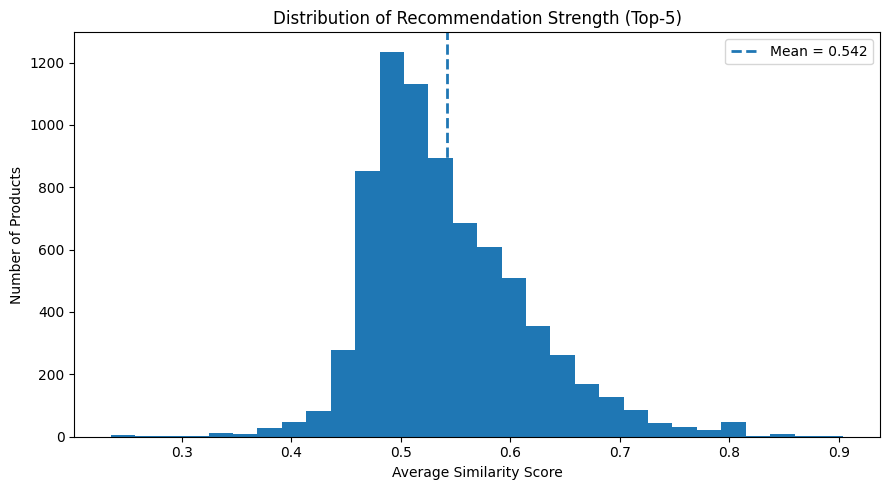

In [11]:
import numpy as np
import matplotlib.pyplot as plt

top_k = 5
avg_similarities = []

n = len(recommender.df)

for i in range(n):
    recs = recommender.get_top_dupes(i, top_n=top_k)

    if len(recs) == 0:
        continue

    avg_similarities.append(recs["similarity"].mean())

avg_similarities = np.array(avg_similarities)
overall_avg = np.mean(avg_similarities)

print("Overall average similarity:", round(overall_avg, 4))

plt.figure(figsize=(9,5))

plt.hist(avg_similarities, bins=30)

plt.axvline(
    overall_avg,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {overall_avg:.3f}"
)

plt.title(f"Distribution of Recommendation Strength (Top-{top_k})")
plt.xlabel("Average Similarity Score")
plt.ylabel("Number of Products")
plt.legend()

plt.tight_layout()
plt.show()

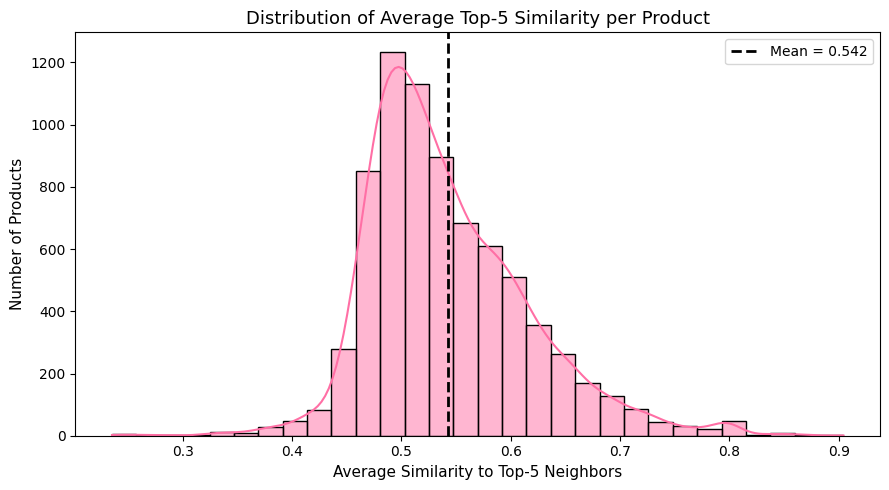

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.histplot(
    avg_similarities,
    bins=30,
    kde=True,
    color="#ff6fa5"
)

plt.axvline(
    overall_avg,
    linestyle="--",
    linewidth=2,
    color="black",
    label=f"Mean = {overall_avg:.3f}"
)

plt.title("Distribution of Average Top-5 Similarity per Product", fontsize=13)
plt.xlabel("Average Similarity to Top-5 Neighbors", fontsize=11)
plt.ylabel("Number of Products", fontsize=11)

plt.legend()
plt.tight_layout()
plt.show()

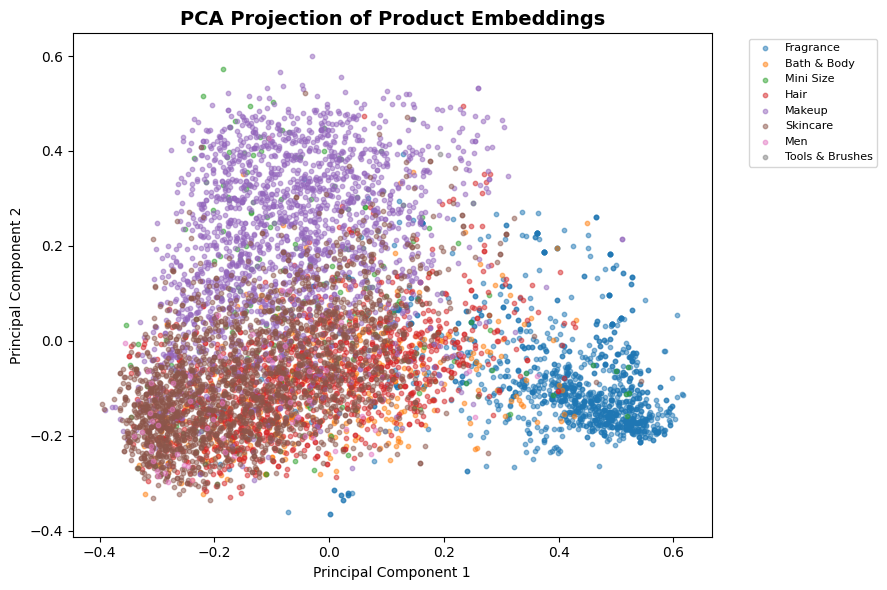

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Run PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(recommender.embeddings)

# Get categories
categories = recommender.df["primary_category"]

# Plot
plt.figure(figsize=(9,6))

for cat in categories.unique():
    idx = categories == cat
    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        s=10,
        alpha=0.5,
        label=cat
    )

plt.title("PCA Projection of Product Embeddings", fontsize=14, weight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()